Loaded upgrade_cohort : (15684, 79)
  risky_upgrade (clustering target) : 1,308
  safe_upgrade  (reference)         : 14,376
Clustering features : 16
Minimum cluster size : 66 (5% of sample)

Feature matrix shape : (1308, 16)

[Step 1] K selection (K=2 to 8)...
  Selection pool: K >= 3 AND min cluster size >= 66
  K=2  sil=0.3478  dbi=1.7624  min_cluster=233  eligible=False  [K < MIN_K]
  K=3  sil=0.3638  dbi=1.5790  min_cluster=25  eligible=False  [min cluster n=25 < 66]
  K=4  sil=0.1395  dbi=1.9309  min_cluster=25  eligible=False  [min cluster n=25 < 66]
  K=5  sil=0.1408  dbi=2.0154  min_cluster=25  eligible=False  [min cluster n=25 < 66]
  K=6  sil=0.1516  dbi=1.8103  min_cluster=25  eligible=False  [min cluster n=25 < 66]
  K=7  sil=0.1585  dbi=1.7725  min_cluster=24  eligible=False  [min cluster n=24 < 66]
  K=8  sil=0.1034  dbi=1.7180  min_cluster=10  eligible=False  [min cluster n=10 < 66]

  All K >= 3 have at least one cluster smaller than 66.
  Fallback: selecting from K >=

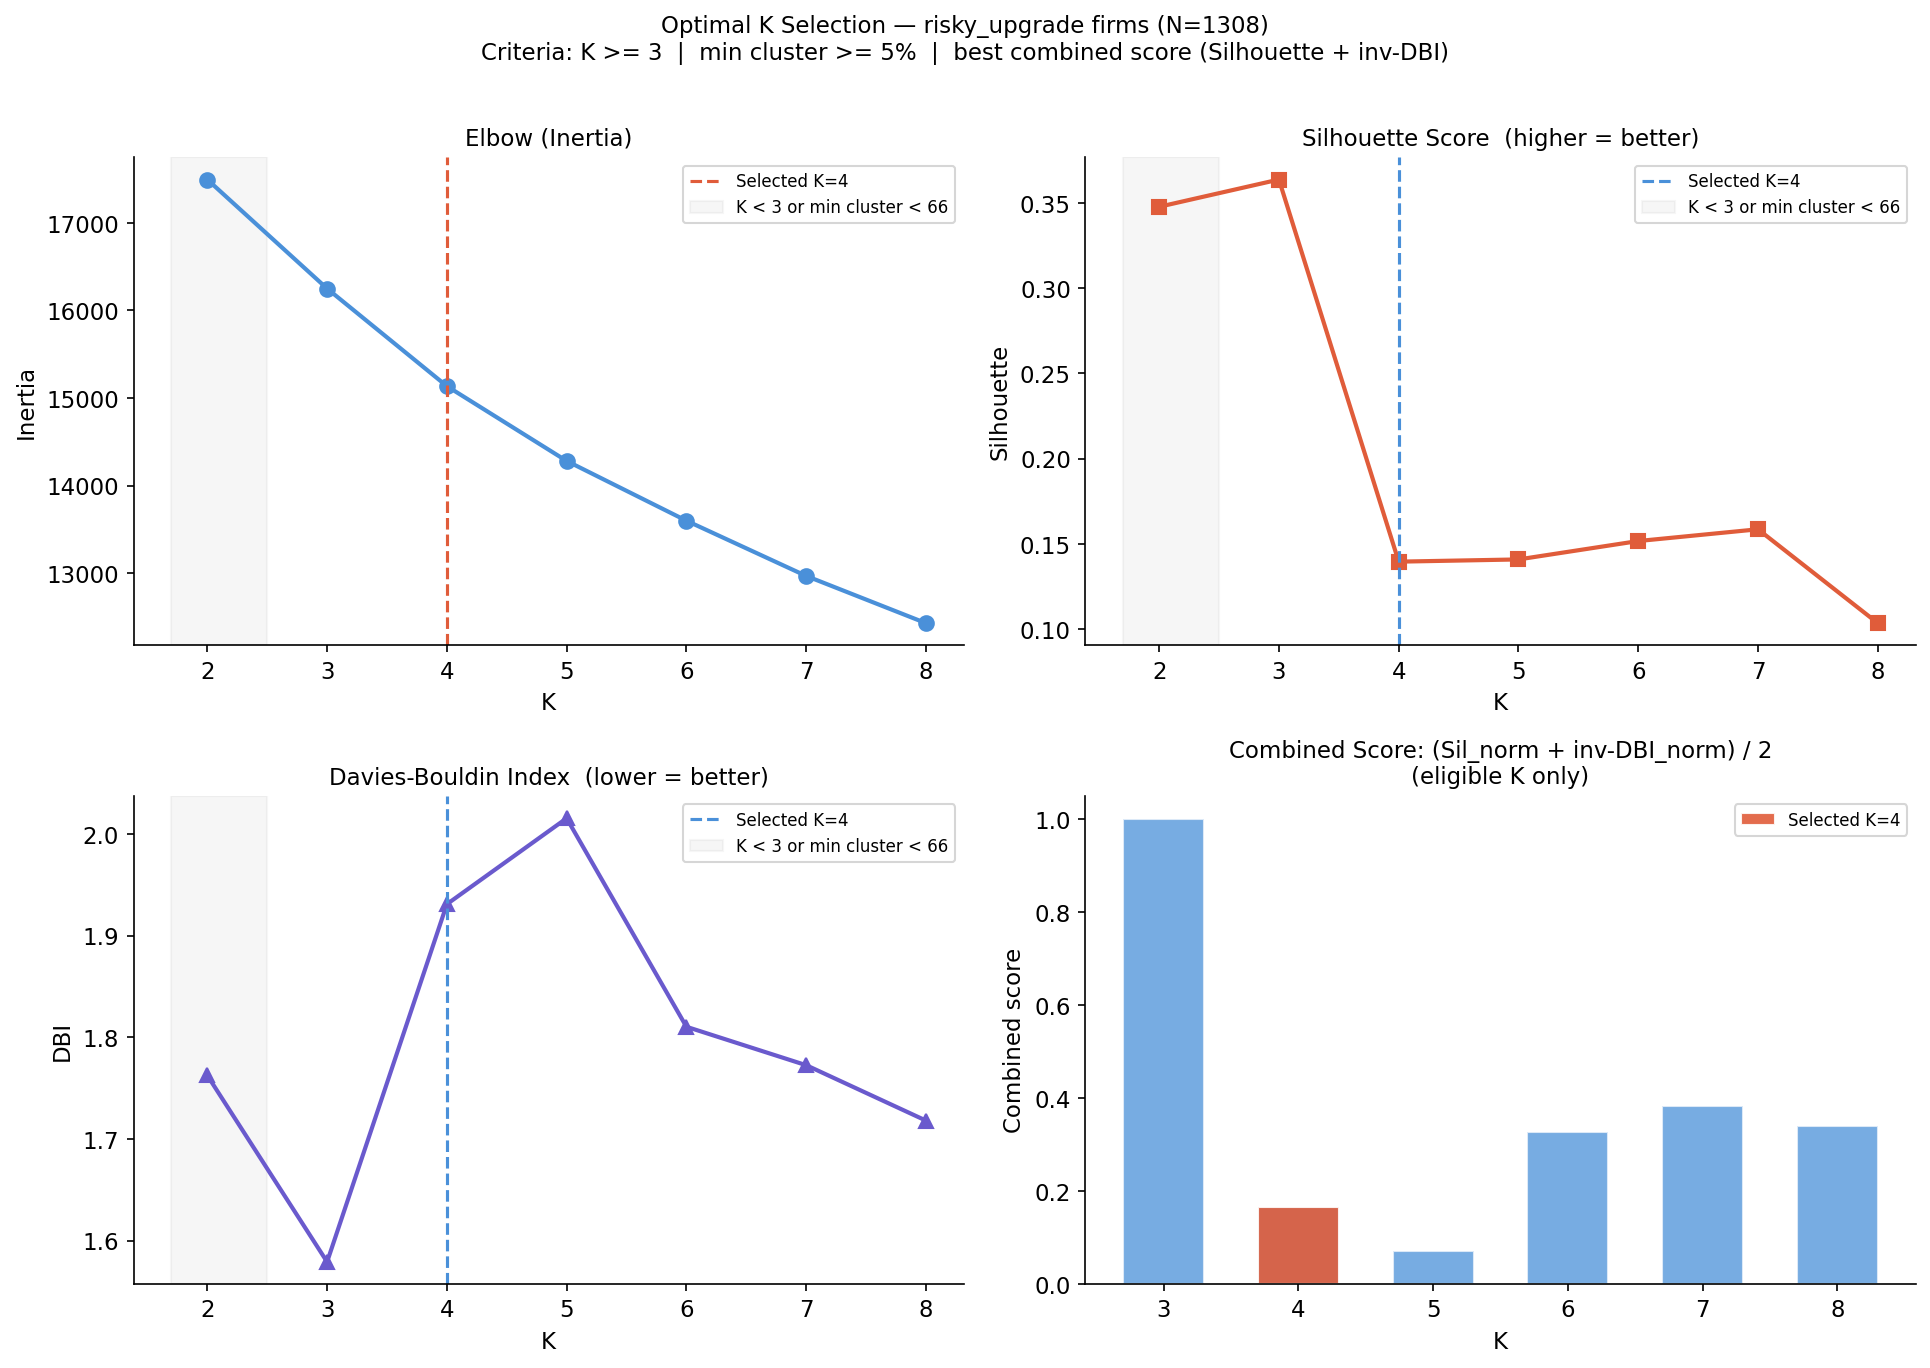

Figure saved: NB05_01_elbow_silhouette.png

[Step 2] Fitting K-Means with K = 4...
Cluster sizes:
cluster
0    191
1    743
2     25
3    349

  This may occur due to random initialisation variance.
  Consider increasing RANDOM_SEED or n_init, or reducing MIN_K.

[Step 3] Computing cluster profiles...

Cluster profiles (relative deviation from safe cohort median):

  Cluster 0  (n=191)
    working_capital_to_assets           rel_dev=-10.500  (cluster=-0.8817  safe=0.0928)  [D]
    Attr25                              rel_dev=-5.690  (cluster=-1.0775  safe=0.2297)  [D]
    Attr24                              rel_dev=-6.803  (cluster=-0.4229  safe=0.0729)  [D]
    Attr30                              rel_dev=+4.739  (cluster=1.6201  safe=0.2823)  [D]
    Attr12                              rel_dev=-5.259  (cluster=-0.2062  safe=0.0484)  [D]
    Attr55                              rel_dev=-9.390  (cluster=-2576.0000  safe=307.0300)  [D]
    Attr41                              rel_dev=-1.980

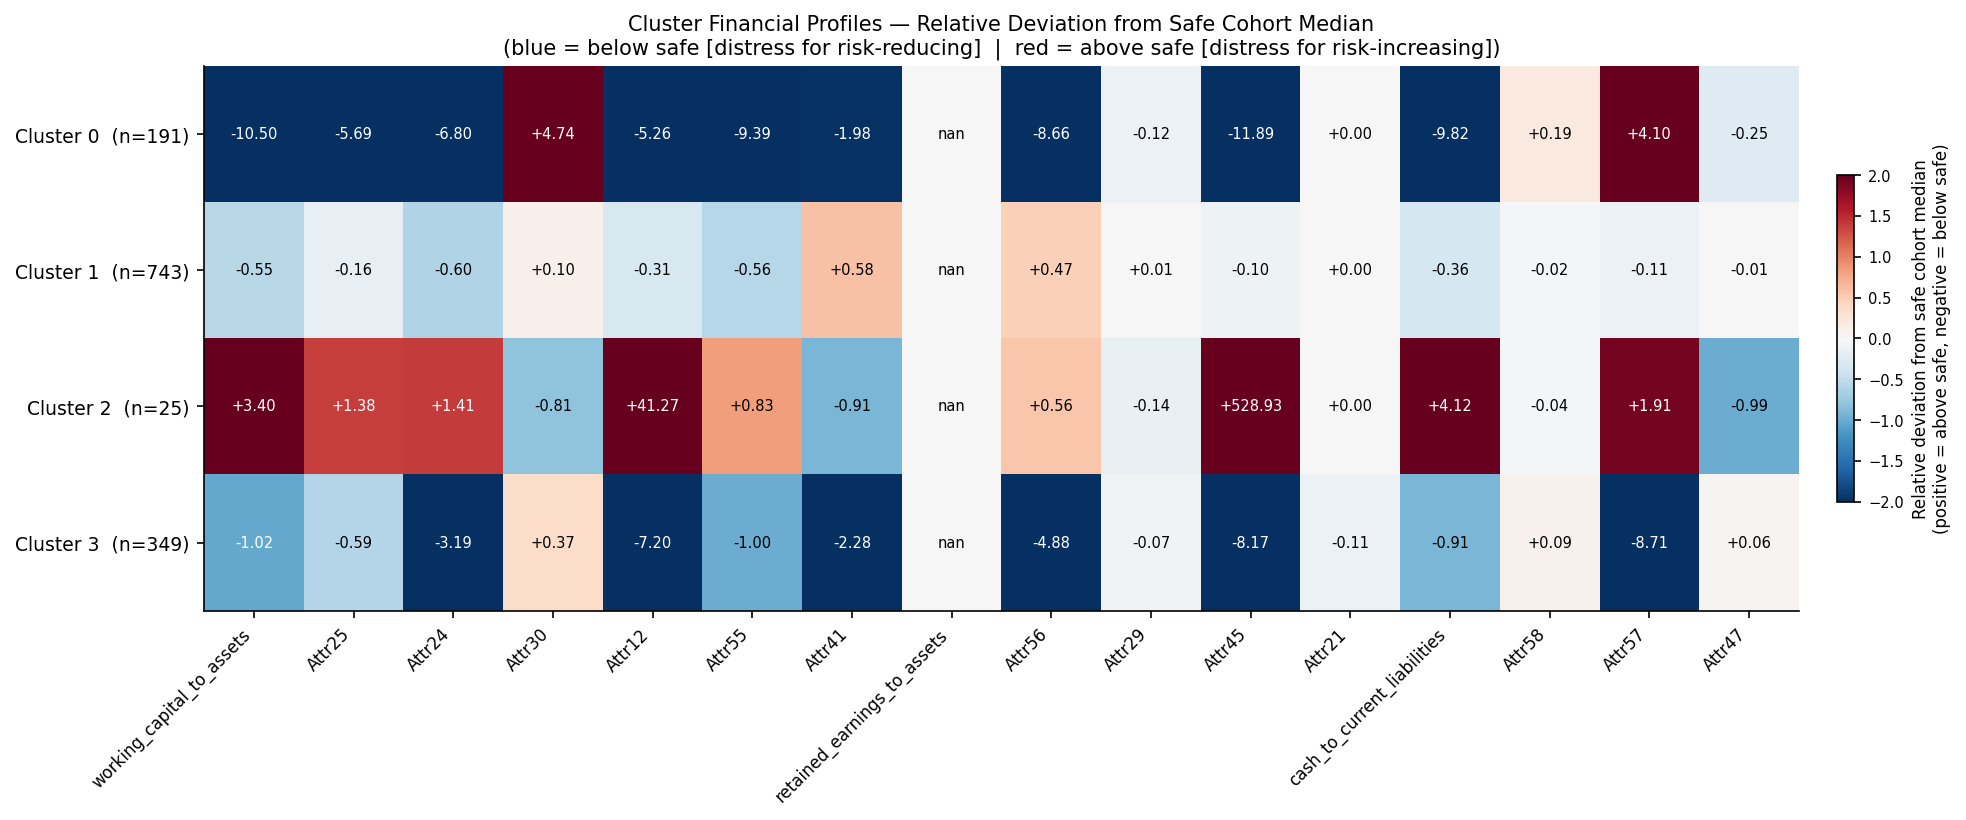

Figure saved: NB05_02_cluster_profiles.png

[Figure 3] PCA cluster scatter


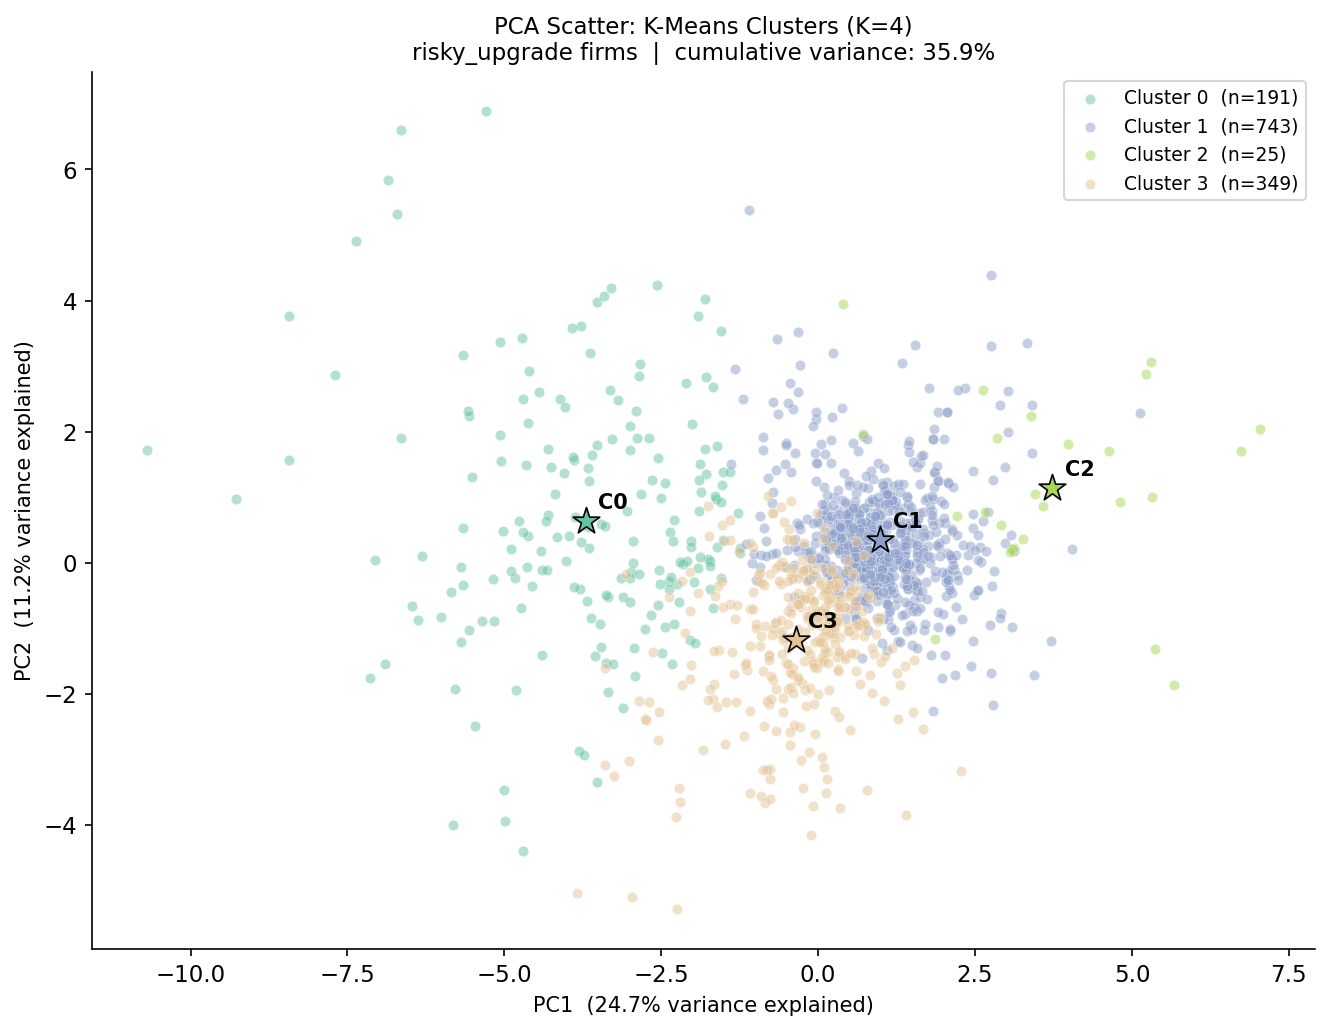

Figure saved: NB05_03_cluster_pca.png

[Figure 4] Box plots — top 6 discriminating variables
  Top 6 discriminating variables (by F-statistic):
    Attr45                              F=599.49
    Attr25                              F=482.83
    Attr12                              F=329.98
    working_capital_to_assets           F=329.96
    retained_earnings_to_assets         F=249.26
    Attr30                              F=243.93


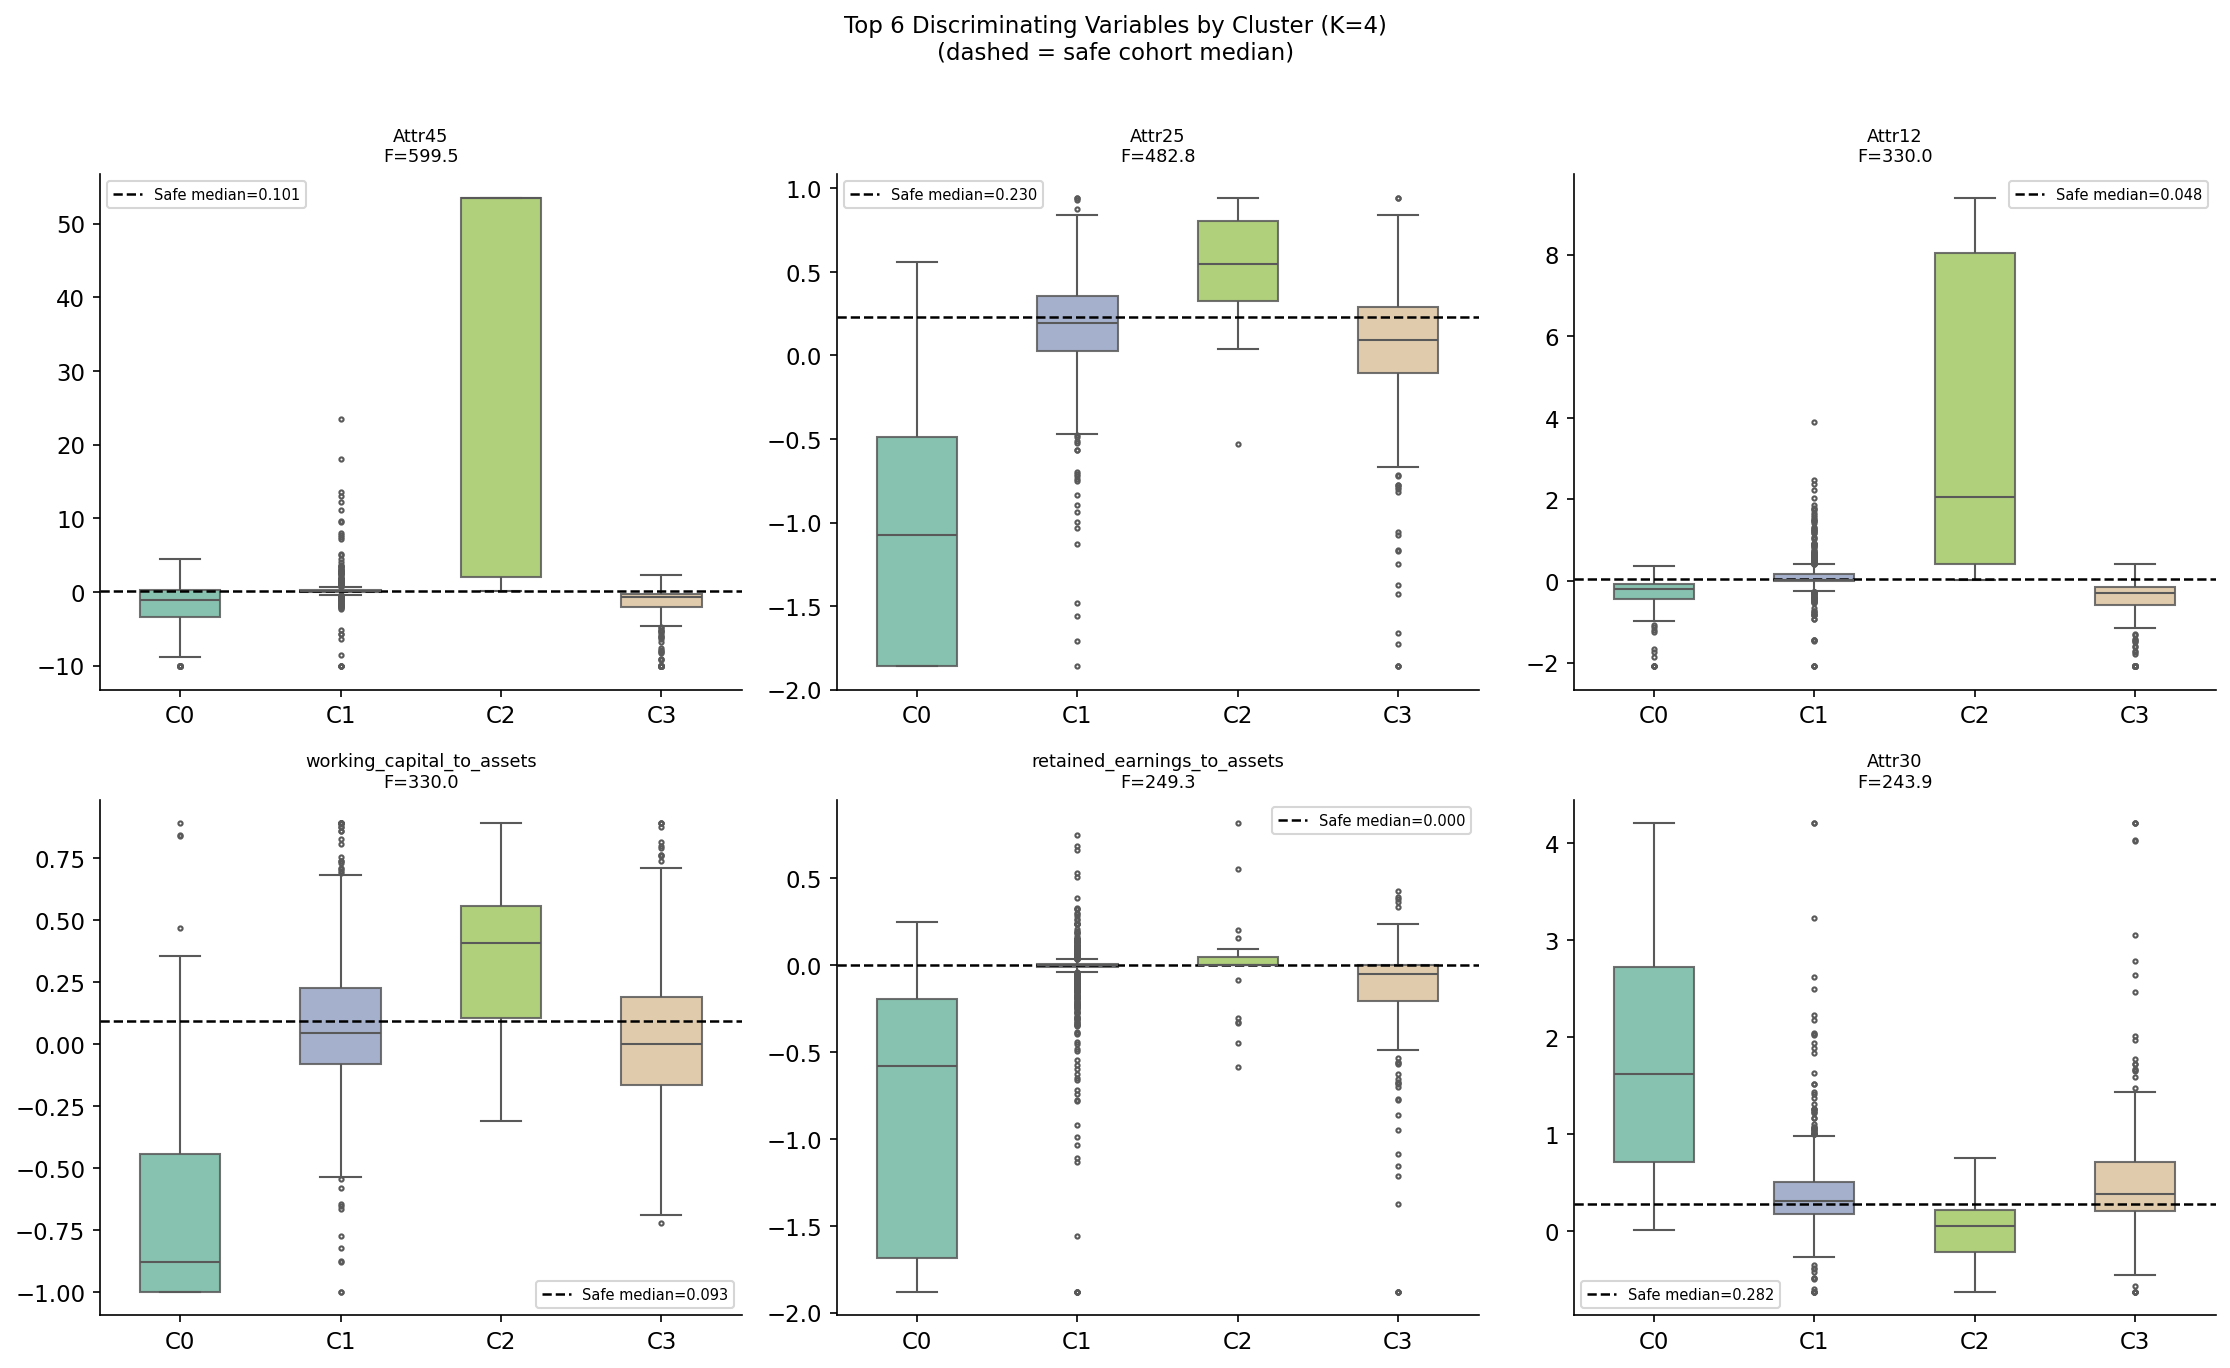

Figure saved: NB05_04_cluster_boxplots.png

NB05 SUMMARY
Optimal K selected         : 4
  Silhouette (K=4)        : 0.1395
  Davies-Bouldin (K=4)    : 1.9309
  Min cluster size (K=4)  : 25 (threshold=66)

Cluster summary:
  Cluster 0  n= 191  dominant signals: ['Attr45', 'working_capital_to_assets', 'cash_to_current_liabilities']
  Cluster 1  n= 743  dominant signals: ['Attr24', 'Attr55', 'working_capital_to_assets']
  Cluster 2  n=  25  dominant signals: ['Attr47', 'Attr41', 'Attr29']
  Cluster 3  n= 349  dominant signals: ['Attr57', 'Attr45', 'Attr12']

K selection rationale (for paper methods section):
  K was selected from the range [3, 8] using two
  complementary internal validity indices — the Silhouette
  coefficient (Rousseeuw, 1987) and the Davies-Bouldin index
  (Davies & Bouldin, 1979) — normalised and averaged into a
  combined score. An additional constraint required each cluster
  to contain at least 5% of the sample (n >= 66)
  to ensure sufficient observations for fina

In [4]:
# NB05_clustering.ipynb
# Study 2: K-Means clustering of risky_upgrade firms
#
# Method:
#   K-Means clustering is applied exclusively to risky_upgrade firms to
#   identify distinct financial distress profiles that the evaluator's
#   upgrade decision overlooked.
#
#   Optimal K selection criteria (all three must be satisfied):
#   (1) K >= MIN_K (minimum 3 for judgment factor interpretability)
#   (2) Minimum cluster size >= MIN_CLUSTER_PCT of sample (5%)
#       — prevents trivially small clusters from inflating silhouette
#   (3) Best combined score: Silhouette (higher = better) +
#       Davies-Bouldin Index (lower = better, normalised to [0,1])
#       — two complementary metrics that agree on the same K
#
# Reference: Tibshirani et al. (2001); Davies & Bouldin (1979)
#
# Input  : data/processed/upgrade_cohort.parquet
#           results/tables/NB03b_variable_map.csv
# Outputs:
#   results/tables/NB05_01_cluster_profiles.csv
#   results/tables/NB05_02_cluster_assignments.csv
#   results/tables/NB05_03_k_selection.csv
#   results/figures/NB05_01_elbow_silhouette.png
#   results/figures/NB05_02_cluster_profiles.png
#   results/figures/NB05_03_cluster_pca.png
#   results/figures/NB05_04_cluster_boxplots.png

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy import stats

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi"       : 150,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.size"        : 11,
    "font.family"      : "DejaVu Sans",
})

PROC_DIR  = "../data/processed/"
FIG_DIR   = "../results/figures/"
TABLE_DIR = "../results/tables/"

os.makedirs(FIG_DIR,   exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

RANDOM_SEED      = 42
MIN_K            = 3      # minimum clusters for interpretability
MAX_K            = 8
MIN_CLUSTER_PCT  = 0.05   # each cluster must contain >= 5% of sample


# ── Load data ─────────────────────────────────────────────────────────────────

cohort     = pd.read_parquet(PROC_DIR + "upgrade_cohort.parquet")
var_map    = pd.read_csv(TABLE_DIR + "NB03b_variable_map.csv", index_col=0)
final_vars = var_map.index.tolist()

risky = cohort[cohort["group"] == "risky_upgrade"].copy()
safe  = cohort[cohort["group"] == "safe_upgrade"].copy()

N_RISKY      = len(risky)
MIN_CLUSTER_N = int(np.ceil(N_RISKY * MIN_CLUSTER_PCT))

print(f"Loaded upgrade_cohort : {cohort.shape}")
print(f"  risky_upgrade (clustering target) : {N_RISKY:,}")
print(f"  safe_upgrade  (reference)         : {len(safe):,}")
print(f"Clustering features : {len(final_vars)}")
print(f"Minimum cluster size : {MIN_CLUSTER_N} ({MIN_CLUSTER_PCT*100:.0f}% of sample)")

safe_medians = safe[final_vars].median()


# ── Prepare feature matrix ────────────────────────────────────────────────────

X_risky  = risky[final_vars].copy().fillna(risky[final_vars].median())
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_risky)

print(f"\nFeature matrix shape : {X_scaled.shape}")


# ── K selection — Silhouette + Davies-Bouldin + min cluster size ──────────────

print(f"\n[Step 1] K selection (K=2 to {MAX_K})...")
print(f"  Selection pool: K >= {MIN_K} AND min cluster size >= {MIN_CLUSTER_N}")

K_RANGE   = range(2, MAX_K + 1)
k_results = []

for k in K_RANGE:
    # Use n_init=50 consistently — same setting as final fit — to ensure
    # cluster size estimates in selection match the final fitted model.
    km   = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=50)
    lbl  = km.fit_predict(X_scaled)
    sil  = silhouette_score(X_scaled, lbl)
    dbi  = davies_bouldin_score(X_scaled, lbl)
    ine  = km.inertia_
    sizes = np.bincount(lbl)
    min_size = sizes.min()
    eligible = (k >= MIN_K) and (min_size >= MIN_CLUSTER_N)

    k_results.append({
        "K"           : k,
        "inertia"     : round(ine, 1),
        "silhouette"  : round(sil, 4),
        "davies_bouldin": round(dbi, 4),
        "min_cluster_n": int(min_size),
        "eligible"    : eligible,
    })

    flag = ""
    if k < MIN_K:
        flag = "  [K < MIN_K]"
    elif min_size < MIN_CLUSTER_N:
        flag = f"  [min cluster n={min_size} < {MIN_CLUSTER_N}]"
    print(f"  K={k}  sil={sil:.4f}  dbi={dbi:.4f}  "
          f"min_cluster={min_size}  eligible={eligible}{flag}")

k_df = pd.DataFrame(k_results).set_index("K")

# Among eligible K values, compute combined score.
# k_df is indexed by K, so filter via index directly.
eligible_df = k_df[k_df["eligible"]].copy()

if len(eligible_df) == 0:
    print("\nWARNING: No K satisfies all criteria.")
    print(f"  All K >= {MIN_K} have at least one cluster smaller than {MIN_CLUSTER_N}.")
    print(f"  Fallback: selecting from K >= {MIN_K} ignoring min_cluster_size constraint.")
    print(f"  Rationale: small clusters reflect genuine extreme distress cases")
    print(f"  that are analytically informative despite their size.")
    eligible_df = k_df[k_df.index >= MIN_K].copy()

sil_min, sil_max = eligible_df["silhouette"].min(), eligible_df["silhouette"].max()
dbi_min, dbi_max = eligible_df["davies_bouldin"].min(), eligible_df["davies_bouldin"].max()

eligible_df["sil_norm"] = (eligible_df["silhouette"] - sil_min) / (sil_max - sil_min + 1e-9)
eligible_df["dbi_norm"] = 1 - (eligible_df["davies_bouldin"] - dbi_min) / (dbi_max - dbi_min + 1e-9)
eligible_df["combined_score"] = (eligible_df["sil_norm"] + eligible_df["dbi_norm"]) / 2

# If all K failed the min_cluster_size check, use Elbow K as primary candidate.
# Elbow K is defined as the point of maximum curvature (second derivative).
inertia_arr = np.array(k_df["inertia"].tolist())
d2          = np.diff(np.diff(inertia_arr))
elbow_k     = list(K_RANGE)[np.argmax(d2) + 1]

if k_df["eligible"].sum() == 0:
    # Fallback selection: use Elbow K if it satisfies K >= MIN_K,
    # otherwise fall back to combined score among K >= MIN_K.
    if elbow_k >= MIN_K:
        OPTIMAL_K = elbow_k
        print(f"\n  Fallback selection: using Elbow K = {OPTIMAL_K}")
        print(f"  (Elbow is preferred over combined score when min_cluster_size")
        print(f"   cannot be satisfied, as it is determined purely from inertia")
        print(f"   without dependence on cluster size distribution.)")
    else:
        OPTIMAL_K = int(eligible_df["combined_score"].idxmax())
        print(f"\n  Fallback selection: using combined score K = {OPTIMAL_K}")
else:
    OPTIMAL_K = int(eligible_df["combined_score"].idxmax())
    print(f"\n  Selected K = {OPTIMAL_K} (all criteria satisfied)")

out_path = TABLE_DIR + "NB05_03_k_selection.csv"
k_df.to_csv(out_path)
print(f"  Saved K selection table: {out_path}")


# ── Figure 1: K selection — 2×2 panel ────────────────────────────────────────

print("\n[Figure 1] K selection plots")

ks   = list(K_RANGE)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
ax_ine, ax_sil, ax_dbi, ax_comb = axes.flatten()

# Eligible zone shading helper
def shade_excluded(ax, ks):
    ax.axvspan(min(ks) - 0.3, MIN_K - 0.5, alpha=0.07, color="grey",
               label=f"K < {MIN_K} or min cluster < {MIN_CLUSTER_N}")

# Inertia
ax_ine.plot(ks, k_df["inertia"], "o-", color="#4A90D9", linewidth=2, markersize=7)
ax_ine.axvline(OPTIMAL_K, color="#E05C3A", linestyle="--", linewidth=1.5,
               label=f"Selected K={OPTIMAL_K}")
shade_excluded(ax_ine, ks)
ax_ine.set_title("Elbow (Inertia)", fontsize=11)
ax_ine.set_xlabel("K")
ax_ine.set_ylabel("Inertia")
ax_ine.set_xticks(ks)
ax_ine.legend(fontsize=8)

# Silhouette
ax_sil.plot(ks, k_df["silhouette"], "s-", color="#E05C3A", linewidth=2, markersize=7)
ax_sil.axvline(OPTIMAL_K, color="#4A90D9", linestyle="--", linewidth=1.5,
               label=f"Selected K={OPTIMAL_K}")
shade_excluded(ax_sil, ks)
ax_sil.set_title("Silhouette Score  (higher = better)", fontsize=11)
ax_sil.set_xlabel("K")
ax_sil.set_ylabel("Silhouette")
ax_sil.set_xticks(ks)
ax_sil.legend(fontsize=8)

# Davies-Bouldin
ax_dbi.plot(ks, k_df["davies_bouldin"], "^-", color="#6A5ACD",
            linewidth=2, markersize=7)
ax_dbi.axvline(OPTIMAL_K, color="#4A90D9", linestyle="--", linewidth=1.5,
               label=f"Selected K={OPTIMAL_K}")
shade_excluded(ax_dbi, ks)
ax_dbi.set_title("Davies-Bouldin Index  (lower = better)", fontsize=11)
ax_dbi.set_xlabel("K")
ax_dbi.set_ylabel("DBI")
ax_dbi.set_xticks(ks)
ax_dbi.legend(fontsize=8)

# Combined score (eligible only)
elig_ks     = eligible_df.index.tolist()
elig_scores = eligible_df["combined_score"].tolist()
ax_comb.bar(elig_ks, elig_scores, color="#4A90D9", alpha=0.75,
            edgecolor="white", width=0.6)
ax_comb.bar([OPTIMAL_K],
            [eligible_df.loc[OPTIMAL_K, "combined_score"]],
            color="#E05C3A", alpha=0.90, edgecolor="white", width=0.6,
            label=f"Selected K={OPTIMAL_K}")
ax_comb.set_title("Combined Score: (Sil_norm + inv-DBI_norm) / 2\n"
                  "(eligible K only)", fontsize=11)
ax_comb.set_xlabel("K")
ax_comb.set_ylabel("Combined score")
ax_comb.set_xticks(elig_ks)
ax_comb.legend(fontsize=8)

plt.suptitle(
    f"Optimal K Selection — risky_upgrade firms (N={N_RISKY})\n"
    f"Criteria: K >= {MIN_K}  |  min cluster >= {MIN_CLUSTER_PCT*100:.0f}%"
    f"  |  best combined score (Silhouette + inv-DBI)",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig(FIG_DIR + "NB05_01_elbow_silhouette.png", bbox_inches="tight")
plt.show()
print("Figure saved: NB05_01_elbow_silhouette.png")


# ── Fit final K-Means ─────────────────────────────────────────────────────────

print(f"\n[Step 2] Fitting K-Means with K = {OPTIMAL_K}...")

# Re-fit with the same parameters used in selection (n_init=50, same seed)
# to guarantee cluster sizes match the eligible check performed in Step 1.
km_final         = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_SEED, n_init=50)
risky            = risky.copy()
risky["cluster"] = km_final.fit_predict(X_scaled)

sizes_final = risky["cluster"].value_counts().sort_index()
print("Cluster sizes:")
print(sizes_final.to_string())

# Post-fit size validation
min_size_final = sizes_final.min()
if min_size_final < MIN_CLUSTER_N:
    print(f"\nWARNING: Smallest cluster has n={min_size_final} < {MIN_CLUSTER_N}.")
    print("  This may occur due to random initialisation variance.")
    print("  Consider increasing RANDOM_SEED or n_init, or reducing MIN_K.")
else:
    print(f"\n[OK] All clusters meet minimum size requirement (n >= {MIN_CLUSTER_N}).")


# ── Cluster profiles ──────────────────────────────────────────────────────────

print("\n[Step 3] Computing cluster profiles...")

profile_rows = []
for k in range(OPTIMAL_K):
    mask = risky["cluster"] == k
    sub  = risky[mask]
    row  = {"cluster": k, "n": int(mask.sum())}
    for col in final_vars:
        c_med = sub[col].median()
        s_med = safe_medians[col]
        row[f"{col}_median"]      = round(c_med, 4)
        row[f"{col}_safe_median"] = round(s_med, 4)
        row[f"{col}_rel_dev"]     = (
            round((c_med - s_med) / abs(s_med), 3)
            if abs(s_med) > 1e-6 else np.nan
        )
    profile_rows.append(row)

profile_df = pd.DataFrame(profile_rows).set_index("cluster")

print("\nCluster profiles (relative deviation from safe cohort median):")
for k in range(OPTIMAL_K):
    print(f"\n  Cluster {k}  (n={int(profile_df.loc[k, 'n'])})")
    for col in final_vars:
        c_med     = profile_df.loc[k, f"{col}_median"]
        s_med     = profile_df.loc[k, f"{col}_safe_median"]
        rel_dev   = profile_df.loc[k, f"{col}_rel_dev"]
        direction = var_map.loc[col, "direction"]
        is_distress = (
            (direction == "risk-reducing"   and pd.notna(rel_dev) and rel_dev < -0.20) or
            (direction == "risk-increasing" and pd.notna(rel_dev) and rel_dev >  0.20)
        )
        flag = "  [D]" if is_distress else ""
        print(f"    {col:<35s} rel_dev={rel_dev:+.3f}  "
              f"(cluster={c_med:.4f}  safe={s_med:.4f}){flag}")

out_path = TABLE_DIR + "NB05_01_cluster_profiles.csv"
profile_df.to_csv(out_path)
print(f"\nSaved: {out_path}")


# ── Cluster labelling ─────────────────────────────────────────────────────────

print("\n[Step 4] Identifying dominant distress signals per cluster...")

cluster_labels = {}
for k in range(OPTIMAL_K):
    distress_scores = {}
    for col in final_vars:
        rel_dev   = profile_df.loc[k, f"{col}_rel_dev"]
        direction = var_map.loc[col, "direction"]
        if pd.isna(rel_dev):
            continue
        score = -rel_dev if direction == "risk-reducing" else rel_dev
        distress_scores[col] = score

    top3 = sorted(distress_scores.items(), key=lambda x: x[1], reverse=True)[:3]
    cluster_labels[k] = {
        "dominant_signals": [t[0]           for t in top3],
        "distress_scores" : [round(t[1], 3) for t in top3],
    }

print()
for k in range(OPTIMAL_K):
    n  = int(profile_df.loc[k, "n"])
    ds = cluster_labels[k]["dominant_signals"]
    sc = cluster_labels[k]["distress_scores"]
    print(f"  Cluster {k}  (n={n})")
    for feat, score in zip(ds, sc):
        print(f"    {feat:<35s} distress_score={score:.3f}")

risky_out = risky[
    ["group", "is_risky", "cluster", "from_grade", "to_grade",
     "transition", "high_risk_transition"] + final_vars
].copy()
out_path = TABLE_DIR + "NB05_02_cluster_assignments.csv"
risky_out.to_csv(out_path)
print(f"\nSaved: {out_path}")


# ── Figure 2: Cluster profiles heatmap ───────────────────────────────────────

print("\n[Figure 2] Cluster profiles heatmap")

heat_data = np.array([
    [profile_df.loc[k, f"{col}_rel_dev"] for col in final_vars]
    for k in range(OPTIMAL_K)
], dtype=float)
heat_capped = np.clip(np.nan_to_num(heat_data, nan=0.0), -2.0, 2.0)

row_labels = [
    f"Cluster {k}  (n={int(profile_df.loc[k, 'n'])})"
    for k in range(OPTIMAL_K)
]

fig, ax = plt.subplots(
    figsize=(max(14, len(final_vars) * 0.9), max(4, OPTIMAL_K * 1.4))
)
im = ax.imshow(heat_capped, aspect="auto", cmap="RdBu_r",
               interpolation="nearest", vmin=-2.0, vmax=2.0)
ax.set_xticks(np.arange(len(final_vars)))
ax.set_xticklabels(final_vars, rotation=45, ha="right", fontsize=8)
ax.set_yticks(np.arange(OPTIMAL_K))
ax.set_yticklabels(row_labels, fontsize=9)

for k in range(OPTIMAL_K):
    for j in range(len(final_vars)):
        val = heat_data[k, j]
        ax.text(j, k, f"{val:+.2f}" if pd.notna(val) else "nan",
                ha="center", va="center", fontsize=7,
                color="white" if abs(val) > 1.0 else "black")

cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("Relative deviation from safe cohort median\n"
               "(positive = above safe, negative = below safe)", fontsize=8)
cbar.ax.tick_params(labelsize=7)
ax.set_title(
    "Cluster Financial Profiles — Relative Deviation from Safe Cohort Median\n"
    "(blue = below safe [distress for risk-reducing]  |"
    "  red = above safe [distress for risk-increasing])",
    fontsize=10,
)
plt.tight_layout()
plt.savefig(FIG_DIR + "NB05_02_cluster_profiles.png", bbox_inches="tight")
plt.show()
print("Figure saved: NB05_02_cluster_profiles.png")


# ── Figure 3: PCA scatter ─────────────────────────────────────────────────────

print("\n[Figure 3] PCA cluster scatter")

pca     = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca   = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_

CLUSTER_COLORS = plt.cm.Set2(np.linspace(0, 0.8, OPTIMAL_K))

fig, ax = plt.subplots(figsize=(9, 7))
for k in range(OPTIMAL_K):
    mask = risky["cluster"] == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[CLUSTER_COLORS[k]], s=25, alpha=0.50,
               edgecolors="white", linewidths=0.3,
               label=f"Cluster {k}  (n={mask.sum()})")
    cx, cy = X_pca[mask, 0].mean(), X_pca[mask, 1].mean()
    ax.scatter(cx, cy, c=[CLUSTER_COLORS[k]], s=180,
               marker="*", edgecolors="black", linewidths=0.8, zorder=6)
    ax.annotate(f"C{k}", xy=(cx, cy), xytext=(6, 6),
                textcoords="offset points", fontsize=10,
                fontweight="bold", color="black")

ax.set_xlabel(f"PC1  ({var_exp[0]*100:.1f}% variance explained)", fontsize=10)
ax.set_ylabel(f"PC2  ({var_exp[1]*100:.1f}% variance explained)", fontsize=10)
ax.set_title(
    f"PCA Scatter: K-Means Clusters (K={OPTIMAL_K})\n"
    f"risky_upgrade firms  |  cumulative variance: {sum(var_exp)*100:.1f}%",
    fontsize=11,
)
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig(FIG_DIR + "NB05_03_cluster_pca.png", bbox_inches="tight")
plt.show()
print("Figure saved: NB05_03_cluster_pca.png")


# ── Figure 4: Box plots — top 6 discriminating variables ─────────────────────

print("\n[Figure 4] Box plots — top 6 discriminating variables")

f_stats = {}
for col in final_vars:
    groups = [risky[risky["cluster"] == k][col].dropna().values
              for k in range(OPTIMAL_K)]
    if all(len(g) > 1 for g in groups):
        f, _ = stats.f_oneway(*groups)
        f_stats[col] = f

top6_vars = sorted(f_stats, key=f_stats.get, reverse=True)[:6]
print("  Top 6 discriminating variables (by F-statistic):")
for col in top6_vars:
    print(f"    {col:<35s} F={f_stats[col]:.2f}")

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
plot_data = risky.copy()
plot_data["cluster_label"] = plot_data["cluster"].apply(lambda k: f"C{k}")

for ax, col in zip(axes, top6_vars):
    sns.boxplot(
        data=plot_data, x="cluster_label", y=col, ax=ax,
        palette={f"C{k}": CLUSTER_COLORS[k] for k in range(OPTIMAL_K)},
        order=[f"C{k}" for k in range(OPTIMAL_K)],
        width=0.5, fliersize=2, boxprops=dict(alpha=0.85),
    )
    s_med = safe_medians[col]
    ax.axhline(s_med, color="black", linestyle="--", linewidth=1.2,
               label=f"Safe median={s_med:.3f}")
    ax.set_title(f"{col}\nF={f_stats[col]:.1f}", fontsize=8.5)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.legend(fontsize=7)

plt.suptitle(
    f"Top 6 Discriminating Variables by Cluster (K={OPTIMAL_K})\n"
    "(dashed = safe cohort median)",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig(FIG_DIR + "NB05_04_cluster_boxplots.png", bbox_inches="tight")
plt.show()
print("Figure saved: NB05_04_cluster_boxplots.png")


# ── Summary ───────────────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print("NB05 SUMMARY")
print("=" * 65)
print(f"Optimal K selected         : {OPTIMAL_K}")
print(f"  Silhouette (K={OPTIMAL_K})        : "
      f"{k_df.loc[OPTIMAL_K, 'silhouette']:.4f}")
print(f"  Davies-Bouldin (K={OPTIMAL_K})    : "
      f"{k_df.loc[OPTIMAL_K, 'davies_bouldin']:.4f}")
print(f"  Min cluster size (K={OPTIMAL_K})  : "
      f"{k_df.loc[OPTIMAL_K, 'min_cluster_n']} "
      f"(threshold={MIN_CLUSTER_N})")
print()
print("Cluster summary:")
for k in range(OPTIMAL_K):
    n  = int(profile_df.loc[k, "n"])
    ds = cluster_labels[k]["dominant_signals"]
    print(f"  Cluster {k}  n={n:4d}  dominant signals: {ds}")

print()
print("K selection rationale (for paper methods section):")
print(f"  K was selected from the range [{MIN_K}, {MAX_K}] using two")
print(f"  complementary internal validity indices — the Silhouette")
print(f"  coefficient (Rousseeuw, 1987) and the Davies-Bouldin index")
print(f"  (Davies & Bouldin, 1979) — normalised and averaged into a")
print(f"  combined score. An additional constraint required each cluster")
print(f"  to contain at least {MIN_CLUSTER_PCT*100:.0f}% of the sample (n >= {MIN_CLUSTER_N})")
print(f"  to ensure sufficient observations for financial profile")
print(f"  interpretation. This procedure selected K = {OPTIMAL_K}.")
print()
print("Next step -> NB06_judgment_factors.ipynb")